# Notebook 1 — OSM Data Collection & Rainfall
## Colombo Rainwater Harvesting Study | 27413 Kevin Anjalo

**Pipeline:**
1. Load official DS Division boundaries from GADM shapefile
2. Download buildings from OSM via Overpass API using exact polygon boundaries
3. Collect Colombo daily rainfall 2015–2025 from Open-Meteo API

**Why Overpass with polygon (not bounding box):**
- Queries OSM using the exact GADM boundary shape
- No overlap between cities — each building belongs to exactly one DS division
- No deduplication needed (and no buildings accidentally removed)

**Output files:**
- `data/outputs/buildings.geojson`
- `data/outputs/rainfall.csv`
- `data/outputs/rainfall_monthly.csv`

---
## Step 1 — Setup

In [1]:
import os, json, time, warnings, requests, datetime
from pathlib import Path
from shapely.geometry import Polygon, mapping

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium

warnings.filterwarnings("ignore")
os.environ["SHAPE_RESTORE_SHX"] = "YES"

BASE_DIR = Path().resolve()
RAW_DIR  = BASE_DIR / "data" / "raw"
OUT_DIR  = BASE_DIR / "data" / "outputs"
RAW_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OVERPASS_ENDPOINTS = [
    "https://overpass-api.de/api/interpreter",
    "https://overpass.kumi.systems/api/interpreter",
    "https://maps.mail.ru/osm/tools/overpass/api/interpreter",
]

print("Setup complete")
print(f"  Raw dir : {RAW_DIR}")
print(f"  Out dir : {OUT_DIR}")

Setup complete
  Raw dir : /content/data/raw
  Out dir : /content/data/outputs


---
## Step 2 — Load Official DS Division Boundaries (GADM)

Place `gadm41_LKA_2.shp` + `.dbf` + `.prj` + `.shx` in the same folder as this notebook.

Colombo District — 12 DS Divisions:

  Colombo                             coords:   44  bbox: [6.910,79.840→6.979,79.884]
  Dehiwala-Mount Lavinia              coords:   22  bbox: [6.804,79.859→6.874,79.899]
  Hanwella                            coords:   71  bbox: [6.857,80.063→6.979,80.223]
  Homagama                            coords:   79  bbox: [6.758,79.951→6.914,80.081]
  Kaduwela                            coords:   73  bbox: [6.855,79.903→6.946,80.045]
  Kesbewa                             coords:   40  bbox: [6.747,79.884→6.861,79.970]
  Kolonnawa                           coords:   47  bbox: [6.911,79.874→6.960,79.959]
  Maharagama                          coords:   43  bbox: [6.827,79.887→6.887,79.992]
  Moratuwa                            coords:   21  bbox: [6.715,79.870→6.819,79.908]
  Padukka                             coords:   76  bbox: [6.771,80.042→6.886,80.202]
  Sri Jayawardanapura Kotte           coords:   31  bbox: [6.856,79.880→6.925,79.920]
  Thimbirigasyaya

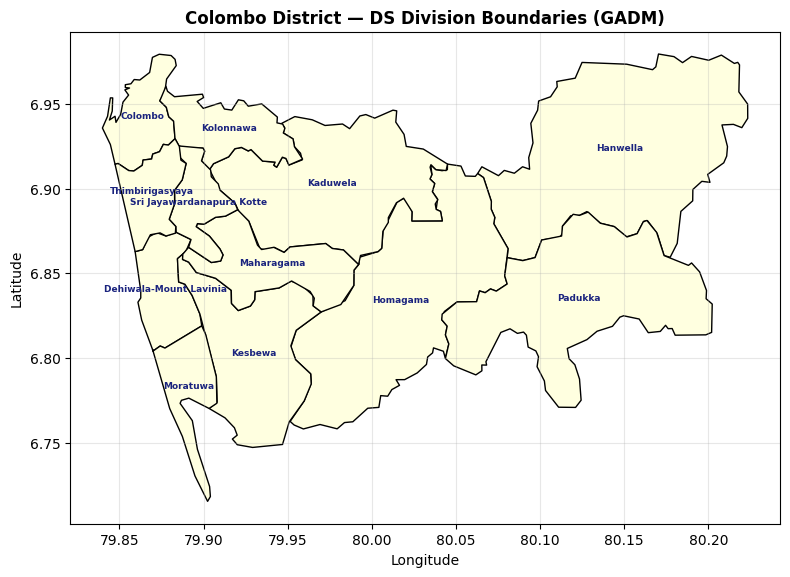

Chart saved: data/outputs/ds_boundaries.png


In [5]:
GADM_SHP = BASE_DIR / "gadm41_LKA_2.shp"

if not GADM_SHP.exists():
    raise FileNotFoundError(
        "gadm41_LKA_2.shp not found.\n"
        "Place the 4 GADM files in the notebook folder."
    )

gdf_gadm    = gpd.read_file(GADM_SHP).to_crs("EPSG:4326")
gdf_colombo = gdf_gadm[gdf_gadm["NAME_1"] == "Colombo"].copy()
gdf_colombo = gdf_colombo.rename(columns={"NAME_2": "city"})

# Simplify to reduce coordinate count (stays within Overpass poly: limit)
gdf_colombo["geometry"] = gdf_colombo.geometry.simplify(tolerance=0.001, preserve_topology=True)

# For MultiPolygon geometries, keep only the largest polygon part
def get_largest_polygon(geom):
    if geom.geom_type == "MultiPolygon":
        return max(geom.geoms, key=lambda g: g.area)
    return geom

gdf_colombo["geometry"] = gdf_colombo["geometry"].apply(get_largest_polygon)

DS_POLYGONS = {row["city"]: row.geometry for _, row in gdf_colombo.iterrows()}

print(f"Colombo District — {len(gdf_colombo)} DS Divisions:")
print()
for name, poly in sorted(DS_POLYGONS.items()):
    b        = poly.bounds
    n_coords = len(list(poly.exterior.coords))
    print(f"  {name:<35} coords: {n_coords:>4}  bbox: [{b[1]:.3f},{b[0]:.3f}→{b[3]:.3f},{b[2]:.3f}]")

# DS Division boundary map
fig, ax = plt.subplots(figsize=(8, 8))
gdf_colombo.plot(ax=ax, edgecolor="black", facecolor="lightyellow", linewidth=1)
for _, row in gdf_colombo.iterrows():
    ax.annotate(
        row["city"],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha="center", fontsize=6.5, color="#1a237e", fontweight="bold"
    )
ax.set_title("Colombo District — DS Division Boundaries (GADM)", fontweight="bold", fontsize=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "ds_boundaries.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: data/outputs/ds_boundaries.png")

---
## Step 3 — Overpass API Download Functions

In [6]:
def polygon_to_poly_str(polygon) -> str:
    """
    Convert Shapely polygon to Overpass API poly: string.
    Format: 'lat1 lon1 lat2 lon2 ...' (note: lat before lon for Overpass)
    """
    coords = list(polygon.exterior.coords)
    return " ".join(f"{lat:.6f} {lon:.6f}" for lon, lat in coords)


def build_overpass_query(poly_str: str) -> str:
    """Build Overpass QL query using polygon boundary."""
    return f"""
[out:json][timeout:120];
(
  way["building"](poly:"{poly_str}");
  relation["building"]["type"="multipolygon"](poly:"{poly_str}");
);
out body;
>;
out skel qt;
"""


def parse_overpass_response(raw: dict, ds_name: str) -> list:
    """Convert Overpass JSON to list of GeoJSON feature dicts."""
    nodes = {
        el["id"]: (el["lon"], el["lat"])
        for el in raw.get("elements", [])
        if el["type"] == "node"
    }

    features = []
    seen_ids  = set()   # prevent way+relation same-polygon duplicates

    for el in raw.get("elements", []):
        if el["type"] not in ("way", "relation"):
            continue
        tags = el.get("tags", {})
        if "building" not in tags:
            continue

        # Unique key: element_type + id (way/123 ≠ relation/123)
        uid = f"{el['type']}/{el['id']}"
        if uid in seen_ids:
            continue
        seen_ids.add(uid)

        try:
            if el["type"] == "way":
                coords = [nodes[nid] for nid in el["nodes"] if nid in nodes]
                if len(coords) < 4:
                    continue
                poly = Polygon(coords)

            else:  # relation / multipolygon
                outer_ways = [m for m in el.get("members", [])
                              if m.get("role") == "outer" and m.get("type") == "way"]
                if not outer_ways:
                    continue
                coords = [nodes[nid] for nid in outer_ways[0].get("ref_nodes", [])
                          if nid in nodes]
                if len(coords) < 4:
                    continue
                poly = Polygon(coords)

            if not poly.is_valid:
                poly = poly.buffer(0)
            if poly.is_empty:
                continue

            features.append({
                "type": "Feature",
                "geometry": mapping(poly),
                "properties": {
                    "osm_id":            str(el["id"]),
                    "osm_type":          el["type"],
                    "city":              ds_name,
                    "building":          tags.get("building", "yes"),
                    "building_levels":   tags.get("building:levels"),
                    "building_material": tags.get("building:material"),
                    "roof_material":     tags.get("roof:material"),
                    "roof_shape":        tags.get("roof:shape"),
                    "name":              tags.get("name"),
                    "addr_street":       tags.get("addr:street"),
                },
            })
        except Exception:
            continue

    return features


def download_buildings(ds_name: str, polygon, cache_path: Path) -> gpd.GeoDataFrame | None:
    """
    Download OSM buildings strictly inside a DS Division polygon via Overpass API.
    Uses poly: filter — no bounding box, no overlap between divisions.
    """
    if cache_path.exists():
        gdf = gpd.read_file(cache_path)
        print(f"  {ds_name:<35} {len(gdf):>8,}  (cached)")
        return gdf

    print(f"  {ds_name:<35} querying ...", end=" ", flush=True)

    poly_str = polygon_to_poly_str(polygon)
    query    = build_overpass_query(poly_str)

    for endpoint in OVERPASS_ENDPOINTS:
        try:
            resp = requests.post(
                endpoint,
                data={"data": query},
                timeout=130,
                headers={"User-Agent": "colombo-rwh-27413/2.0 (academic-research)"},
            )
            if resp.status_code == 200:
                features = parse_overpass_response(resp.json(), ds_name)
                if not features:
                    print("0 buildings")
                    return None
                gjson = {"type": "FeatureCollection", "features": features}
                cache_path.write_text(json.dumps(gjson))
                gdf = gpd.read_file(cache_path)
                print(f"{len(gdf):,} buildings  →  saved")
                return gdf
            elif resp.status_code == 429:
                print(f"Rate limited — waiting 60s ...", end=" ", flush=True)
                time.sleep(60)
            else:
                print(f"HTTP {resp.status_code} from {endpoint.split('/')[2]}")
        except Exception as e:
            print(f"Error ({endpoint.split('/')[2]}): {e}")

    print("All endpoints failed")
    return None

print("Download functions ready")

Download functions ready


---
## Step 4 — Download Buildings for All DS Divisions

In [7]:
all_gdfs    = []
failed      = []
log_records = []

print(f"Downloading {len(DS_POLYGONS)} DS Divisions from OpenStreetMap...")
print(f"{'Division':<35} {'Result':>12}")
print("─" * 50)

for ds_name, polygon in sorted(DS_POLYGONS.items()):
    safe  = ds_name.lower().replace(" ", "_").replace("-", "_")
    cache = RAW_DIR / f"osm_{safe}.geojson"
    gdf   = download_buildings(ds_name, polygon, cache)
    time.sleep(3)   # polite delay between requests

    if gdf is not None and not gdf.empty:
        all_gdfs.append(gdf)
        log_records.append({"city": ds_name, "buildings": len(gdf), "source": "overpass"})
    else:
        failed.append(ds_name)
        log_records.append({"city": ds_name, "buildings": 0, "source": "failed"})

print()
print(f"Loaded : {len(all_gdfs)}/{len(DS_POLYGONS)} divisions")
if failed:
    print(f"Failed : {', '.join(failed)}")

Division                                  Result
──────────────────────────────────────────────────
  Colombo                             querying ... 13,982 buildings  →  saved
  Dehiwala-Mount Lavinia              querying ... 32,450 buildings  →  saved
  Hanwella                            querying ... Rate limited — waiting 60s ... 15,164 buildings  →  saved
  Homagama                            querying ... 11,422 buildings  →  saved
  Kaduwela                            querying ... 32,672 buildings  →  saved
  Kesbewa                             querying ... 21,731 buildings  →  saved
  Kolonnawa                           querying ... 26,530 buildings  →  saved
  Maharagama                          querying ... 21,604 buildings  →  saved
  Moratuwa                            querying ... 32,454 buildings  →  saved
  Padukka                             querying ... 3,889 buildings  →  saved
  Sri Jayawardanapura Kotte           querying ... 8,836 buildings  →  saved
  Thimbirigas

---
## Step 5 — Merge & Save

Since each building was downloaded from its exact DS division polygon with **no overlap**,
there are no cross-city duplicates. No buildings are removed in this step.

In [8]:
if not all_gdfs:
    raise RuntimeError("No data loaded. Check internet connection and re-run.")

# Merge all divisions
gdf_all = gpd.GeoDataFrame(
    pd.concat(all_gdfs, ignore_index=True), crs="EPSG:4326"
)

# Ensure all expected columns exist
for col in ["osm_id","osm_type","city","building","building_levels",
            "building_material","roof_material","roof_shape","name","addr_street"]:
    if col not in gdf_all.columns:
        gdf_all[col] = None

# No deduplication needed — GADM boundaries don't overlap
# Each building physically belongs to exactly one DS division
print(f"Total buildings : {len(gdf_all):,}")
print(f"Cities          : {gdf_all['city'].nunique()}")
print()
print(gdf_all["city"].value_counts().sort_index().to_string())

# Save
merged_path = OUT_DIR / "buildings.geojson"
gdf_all.to_file(merged_path, driver="GeoJSON")
print(f"\nSaved: {merged_path}")

Total buildings : 236,894
Cities          : 12

city
Colombo                      13982
Dehiwala-Mount Lavinia       32450
Hanwella                     15164
Homagama                     11422
Kaduwela                     32672
Kesbewa                      21731
Kolonnawa                    26530
Maharagama                   21604
Moratuwa                     32454
Padukka                       3889
Sri Jayawardanapura Kotte     8836
Thimbirigasyaya              16160

Saved: /content/data/outputs/buildings.geojson


---
## Step 8 — Rainfall Collection (2015–2025)

**API:** Open-Meteo Historical Weather API (free, no key needed)
**Location:** Colombo — 6.9271°N, 79.8612°E

In [11]:
def fetch_openmeteo_rainfall(start_year: int, end_year: int) -> pd.DataFrame:
    url     = "https://archive-api.open-meteo.com/v1/archive"
    records = []

    for year in range(start_year, end_year + 1):
        params = {
            "latitude":   6.9271,
            "longitude":  79.8612,
            "start_date": f"{year}-01-01",
            "end_date":   f"{year}-12-31",
            "daily":      "precipitation_sum",
            "timezone":   "Asia/Colombo",
        }
        try:
            print(f"  Fetching {year} ...", end=" ", flush=True)
            resp = requests.get(url, params=params, timeout=30)

            if resp.status_code == 200:
                data  = resp.json()
                dates = data["daily"]["time"]
                rain  = data["daily"]["precipitation_sum"]
                for dt_str, mm in zip(dates, rain):
                    dt = datetime.date.fromisoformat(dt_str)
                    records.append({
                        "date":             dt_str,
                        "year":             dt.year,
                        "month":            dt.month,
                        "month_name":       dt.strftime("%b"),
                        "day":              dt.day,
                        "precipitation_mm": round(float(mm) if mm else 0.0, 1),
                        "station":          "Colombo",
                        "latitude":         6.9271,
                        "longitude":        79.8612,
                        "source":           "Open-Meteo Historical API (ERA5)",
                    })
                total = sum(r if r else 0 for r in rain)
                print(f"OK  ({total:.0f} mm)")
            elif resp.status_code == 429:
                print("Rate limited — waiting 30s...")
                time.sleep(30)
            else:
                print(f"HTTP {resp.status_code}")
        except Exception as e:
            print(f"Error: {e}")
        time.sleep(1)

    return pd.DataFrame(records)


print("Fetching Colombo rainfall 2015–2025 ...")
df_rain = fetch_openmeteo_rainfall(2015, 2025)

Fetching Colombo rainfall 2015–2025 ...
  Fetching 2015 ... OK  (2928 mm)
  Fetching 2016 ... OK  (2124 mm)
  Fetching 2017 ... OK  (3155 mm)
  Fetching 2018 ... OK  (2438 mm)
  Fetching 2019 ... OK  (2763 mm)
  Fetching 2020 ... OK  (2280 mm)
  Fetching 2021 ... OK  (3096 mm)
  Fetching 2022 ... OK  (2804 mm)
  Fetching 2023 ... OK  (3468 mm)
  Fetching 2024 ... OK  (3301 mm)
  Fetching 2025 ... OK  (2828 mm)


---
## Step 9 — Save Rainfall Data

In [12]:
if df_rain.empty:
    print("API not reachable — check connection and re-run.")
else:
    daily_path = OUT_DIR / "rainfall.csv"
    df_rain.to_csv(daily_path, index=False)

    monthly = (df_rain.groupby(["year","month","month_name"])["precipitation_mm"]
               .sum().reset_index())
    monthly.columns = ["year","month","month_name","monthly_mm"]
    monthly.to_csv(OUT_DIR / "rainfall_monthly.csv", index=False)

    ann = df_rain.groupby("year")["precipitation_mm"].sum()

    print(f"Daily records   : {len(df_rain):,}  ({df_rain['date'].min()} to {df_rain['date'].max()})")
    print(f"Monthly records : {len(monthly):,}")
    print()
    print(f"  {'Year':<8} {'Annual mm':>10}")
    print(f"  {'─'*20}")
    for y, v in ann.items():
        print(f"  {y:<8} {v:>10.0f}")
    print(f"  {'─'*20}")
    print(f"  {'Average':<8} {ann.mean():>10.0f}")
    print()
    print("Summary:")
    print(f"  data/outputs/buildings.geojson       — {len(gdf_all):,} buildings")
    print(f"  data/outputs/rainfall.csv            — daily rainfall")
    print(f"  data/outputs/rainfall_monthly.csv    — monthly aggregates")

Daily records   : 4,018  (2015-01-01 to 2025-12-31)
Monthly records : 132

  Year      Annual mm
  ────────────────────
  2015           2928
  2016           2124
  2017           3155
  2018           2438
  2019           2763
  2020           2280
  2021           3096
  2022           2804
  2023           3468
  2024           3301
  2025           2828
  ────────────────────
  Average        2835

Summary:
  data/outputs/buildings.geojson       — 236,894 buildings
  data/outputs/rainfall.csv            — daily rainfall
  data/outputs/rainfall_monthly.csv    — monthly aggregates
